# Лабораторна робота №1

**Варіант 4**  
**Студент:** Карпенко Артем  

Мета роботи: створити програму для обчислення функції, побудови її графіка і оформлення результатів в Jupyter Lab.

Задана функція:
$$p=\frac{e^{-3x}+\tan(3x-3)}{|\sin x|+\sqrt[4]{\cos x+\cos 2x}}$$

In [1]:
import math

def calculate_p(x):
    numerator = math.exp(-3 * x) + math.tan(3 * x - 3)
    under_root = math.cos(x) + math.cos(2 * x)
    
    if under_root < 0:
        return "Помилка: від'ємне число під коренем"
        
    root_part = under_root ** 0.25
    sin_part = abs(math.sin(x))
    denominator = sin_part + root_part
    
    if denominator < 0.000001:
        return "Помилка: ділення на нуль"
    
    return numerator / denominator

x_values = {
    "0": 0,
    "1": 1,
    "2": 2,
    "pi/2": math.pi / 2,
    "pi": math.pi
}

print("Результати обчислень:")
for name, val in x_values.items():
    result = calculate_p(val)
    print(f"x = {name} ---> {result}")

Результати обчислень:
x = 0 ---> 0.960763292331684
x = 1 ---> 0.03469318524441641
x = 2 ---> Помилка: від'ємне число під коренем
x = pi/2 ---> Помилка: від'ємне число під коренем
x = pi ---> Помилка: ділення на нуль


/tmp/ipykernel_14807/3796883575.py:9: RuntimeWarning: invalid value encountered in power
  root_part = np.where(under_root >= 0, under_root ** 0.25, np.nan)


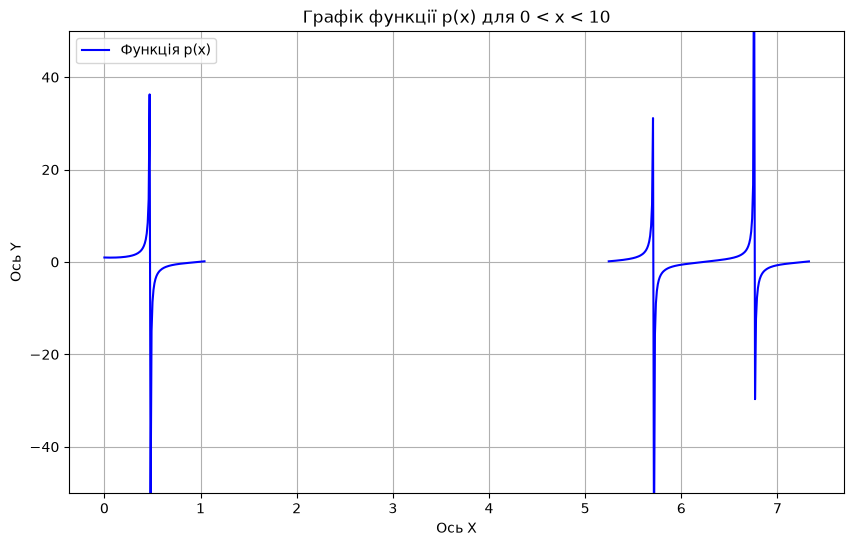

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_p_graph(x):
    numerator = np.exp(-3 * x) + np.tan(3 * x - 3)
    under_root = np.cos(x) + np.cos(2 * x)
    
    # Використовуємо маски numpy для обробки помилок у масивах
    root_part = np.where(under_root >= 0, under_root ** 0.25, np.nan)
    sin_part = np.abs(np.sin(x))
    denominator = sin_part + root_part
    
    # Замінюємо ділення на нуль на nan
    result = np.where(denominator > 0.000001, numerator / denominator, np.nan)
    return result

# Генеруємо 1000 точок від 0 до 10
x_points = np.linspace(0, 10, 1000)
y_points = calculate_p_graph(x_points)

# Налаштовуємо графік
plt.figure(figsize=(10, 6))
plt.plot(x_points, y_points, color='blue', label='Функція p(x)')
plt.title('Графік функції p(x) для 0 < x < 10')
plt.xlabel('Ось X')
plt.ylabel('Ось Y')
plt.ylim(-50, 50) # Обмежуємо вісь Y, щоб графік був більш читабельним
plt.grid(True)
plt.legend()
plt.show()